In [2]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

# Get NIST data

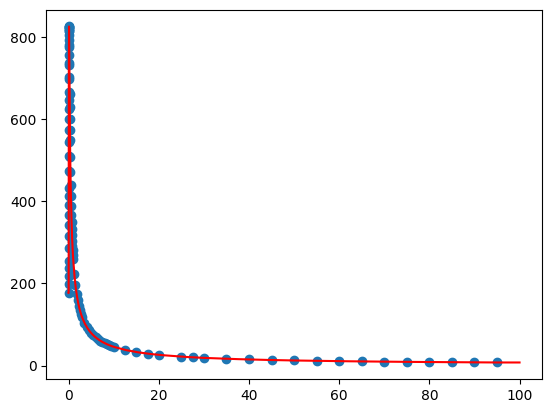

In [3]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

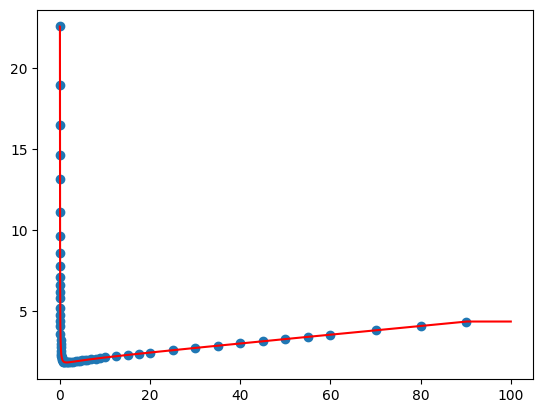

In [4]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# LET and dose statistics

In [5]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        particle_data['Dose_weights'] = particle_data['Weight']*particle_data['LET']
        particle_data['Dose_weights'] = particle_data['Dose_weights']/particle_data['Dose_weights'].sum()
        particle_data['LET_d'] = particle_data['Dose_weights']*particle_data['LET']

        LET = round(particle_data['LET_d'].sum(),2)
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        LET = 0

    #print(phsp_path + ' finished')

    return LET

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_22200\3984868068.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [6]:
# print('---low LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---mid LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---high LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# Analysis of lineal energy spectra

In [66]:
def read_in_spectrum(masterfolder):
    batches = [name for name in os.listdir(masterfolder)]
    count = 0
    ydata = pd.DataFrame(columns=['y', 'fy', 'yfy', 'dy', 'ydy'])
    i=0

    for batch in batches:
        path = os.path.join(masterfolder, batch, 'ySpecfile.txt')

        #read in yspec file
        try:
            y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')
            
            if i==0:
                ydata['y'] = y.iloc[:,0]
                ydata['fy'] = y.iloc[:,1]
                ydata['yfy'] = y.iloc[:,3]
                ydata['dy'] = y.iloc[:,5]
                ydata['ydy'] = y.iloc[:,7]
            
            else:
                ydata['fy'] = ydata['fy'].to_numpy() + y.iloc[:,1].to_numpy()
                ydata['yfy'] = ydata['yfy'] + y.iloc[:,3]
                ydata['dy'] = ydata['dy'] + y.iloc[:,5]
                ydata['ydy'] = ydata['ydy'] + y.iloc[:,7]
            
            i += 1

        except FileNotFoundError:
            continue

        #update particle count
        phsp_path = os.path.join(masterfolder, batch, 'MONASScorer.phsp')
        print(phsp_path)
        count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))

    print(str(i) + ' out of ' + str(len(batches)) + ' batches had particle data')
    print('Number of particles: ' + str(count))

    return ydata

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:35: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_22200\3457593002.py:12: SyntaxWarning: invalid escape sequence '\s'
  y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')
C:\Users\linux\AppData\Local\Temp\ipykernel_22200\3457593002.py:35: SyntaxWarning: invalid escape sequence '\s'
  count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))


In [69]:
ylow = read_in_spectrum(r"C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONAS_LOW")

C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONAS_LOW\Batch10\MONASScorer.phsp
C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONAS_LOW\Batch3\MONASScorer.phsp
C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONAS_LOW\Batch4\MONASScorer.phsp
C:\Users\linux\Documents\Thesis_project\TOPAS_data\OUTPUTS_MONAS_LOW\Batch9\MONASScorer.phsp
4 out of 10 batches had particle data
Number of particles: 1144


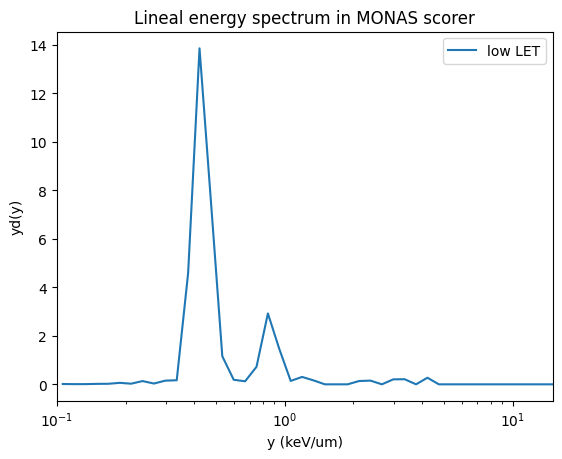

In [70]:
plt.plot(ylow['y'], ylow['ydy'], label='low LET')
# plt.plot(ydata_high.iloc[:,0], ydata_high.iloc[:,3], label='high LET')
plt.xscale('log')
plt.xlim([0.1,15])
plt.xlabel('y (keV/um)')
plt.ylabel('yd(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()

In [54]:
def spectrum_calc(spectrumfile):

    #constants
    y0 = 150
    #cell constants taken from HSG paper for now
    a0 = 0.15
    b = 0.105
    aR = 0.15
    Rd = 0.44
    rho = 1

    #parameters from yspecfile
    y = spectrumfile['y']
    fy = spectrumfile['dy']
    yfy = spectrumfile['ydy']

    #calculate bin widths
    ybins = np.zeros(len(y))
    for i in range(len(y)-1):
        if i == (len(y)-1):
            y[i] = 0
        else:
            ybins[i] = y[i+1] - y[i]

    #calculate ystar
    ystar_nominator = np.square(y0)*np.sum((1-np.exp(-(np.square(y))/np.square(y0)))*fy*ybins)
    ystar_denominator = np.sum(yfy*ybins)
    ystar = ystar_nominator/ystar_denominator

    #calculate survival and RBE data per dose
    data = pd.DataFrame(columns=['Dose', 'S', 'RBE'])
    doses = [2, 5, 8]
    for d in doses:
        newrow = {}
        newrow['Dose'] = d

        #calculate survival
        exponent = -(a0 + ((b)/(rho*math.pi*np.square(Rd)))*ystar*0.16)*d - b*np.square(d)
        newrow['S'] = np.exp(exponent)

        #calculate RBE
        RBE_nominator = np.sqrt(np.square(aR) - 4*b*np.log(newrow['S'])) - aR
        RBE_denominator = 2*b*d
        newrow['RBE'] = RBE_nominator/RBE_denominator

        data = pd.concat([data, pd.DataFrame([newrow])])


    print(data)

In [64]:
spectrum_calc(ylow)

  Dose         S       RBE
0    2  0.462837  1.043497
0    5  0.030169  1.020803
0    8  0.000297  1.013679


C:\Users\linux\AppData\Local\Temp\ipykernel_22200\3536508737.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])
